In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("crop_remmendation_dataset.csv")

# Show first rows
print(df.head())

# Check info
print(df.info())

# Check null values
print(df.isnull().sum())

     N   P   K  Soil_pH  Soil_Moisture Soil_Type  Organic_Carbon  \
0  122  55  74     4.54          58.90      Silt            0.77   
1  112  37  25     7.03          25.98     Sandy            0.66   
2   34  52  39     4.95          27.61      Clay            1.36   
3  126  35  82     7.14          39.97     Loamy            1.09   
4   91  64  51     8.20          33.97     Sandy            0.70   

   Electrical_Conductivity  Temperature  Humidity  Rainfall  Sunlight_Hours  \
0                     0.67        25.31     35.15   1403.58           11.03   
1                     1.94        31.80     54.80   1800.84            4.23   
2                     2.03        15.78     30.88   1336.62           11.45   
3                     0.30        38.23     47.60    480.85            4.71   
4                     2.07        10.04     72.42   2535.23           11.21   

   Wind_Speed   Region  Altitude  Season Irrigation_Type  Fertilizer_Used  \
0        5.98     West      1947  Khari

In [2]:
import numpy as np

# Copy dataset
df_processed = df.copy()

# Select numerical columns
num_cols = df_processed.select_dtypes(include=['int64', 'float64']).columns

# Cap outliers using IQR
for col in num_cols:
    Q1 = df_processed[col].quantile(0.25)
    Q3 = df_processed[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_processed[col] = np.where(df_processed[col] < lower, lower,
                         np.where(df_processed[col] > upper, upper,
                                  df_processed[col]))

print("Outliers handled (capped) ✅")

Outliers handled (capped) ✅


In [3]:
from sklearn.preprocessing import LabelEncoder
import joblib

# Encode categorical columns
categorical_cols = df_processed.select_dtypes(include=['object']).columns

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col])
    encoders[col] = le

# Save encoders
joblib.dump(encoders, "encoders.pkl")

# Split features & target
X = df_processed.drop("Recommended_Crop", axis=1)
y = df_processed["Recommended_Crop"]

# Save feature names
joblib.dump(X.columns.tolist(), "crop_features.pkl")

print("Encoding Done ✅")
print("X shape:", X.shape)
print("y shape:", y.shape)

Encoding Done ✅
X shape: (10000, 19)
y shape: (10000,)


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (8000, 19)
X_test : (2000, 19)
y_train: (8000,)
y_test : (2000,)


In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC()
}

results = {}

for name, model in models.items():
    print("\n==============================")
    print(f"MODEL: {name}")
    print("==============================")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results[name] = acc

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    print("\nDetailed Classification Report:\n")
    print(classification_report(y_test, y_pred))


MODEL: Random Forest
Accuracy : 0.8085
Precision: 0.7890
Recall   : 0.8085
F1 Score : 0.7894

Detailed Classification Report:

              precision    recall  f1-score   support

           0       0.25      0.19      0.21        80
           1       0.43      0.60      0.50        60
           2       0.50      0.02      0.04        43
           3       0.76      0.91      0.82       243
           4       0.19      0.17      0.18        72
           5       0.33      0.03      0.05        36
           6       0.98      0.96      0.97       736
           7       0.87      0.84      0.86       231
           8       0.11      0.05      0.06        22
           9       0.80      0.90      0.84       477

    accuracy                           0.81      2000
   macro avg       0.52      0.47      0.45      2000
weighted avg       0.79      0.81      0.79      2000


MODEL: Decision Tree
Accuracy : 0.8020
Precision: 0.8073
Recall   : 0.8020
F1 Score : 0.8040

Detailed Classific

C:\Users\megha\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\megha\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\megha\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\megha\anaconda3\Lib\site-packag

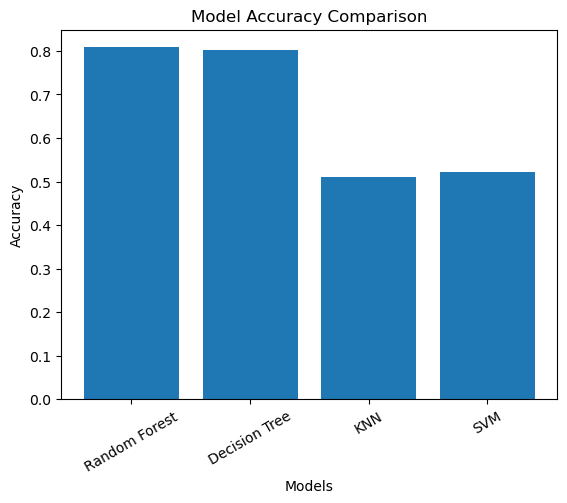

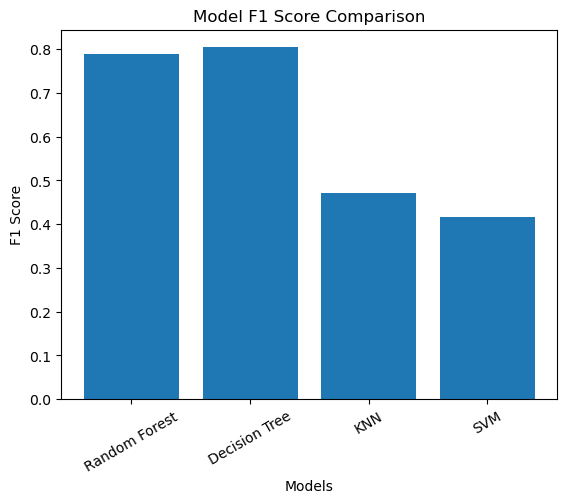

In [6]:
import matplotlib.pyplot as plt

# Store results manually from your output
model_names = ["Random Forest", "Decision Tree", "KNN", "SVM"]

accuracy = [0.8085, 0.8020, 0.5110, 0.5210]
f1_scores = [0.7894, 0.8040, 0.4700, 0.4160]

# Plot Accuracy
plt.figure()
plt.bar(model_names, accuracy)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()

# Plot F1 Score
plt.figure()
plt.bar(model_names, f1_scores)
plt.title("Model F1 Score Comparison")
plt.xlabel("Models")
plt.ylabel("F1 Score")
plt.xticks(rotation=30)
plt.show()

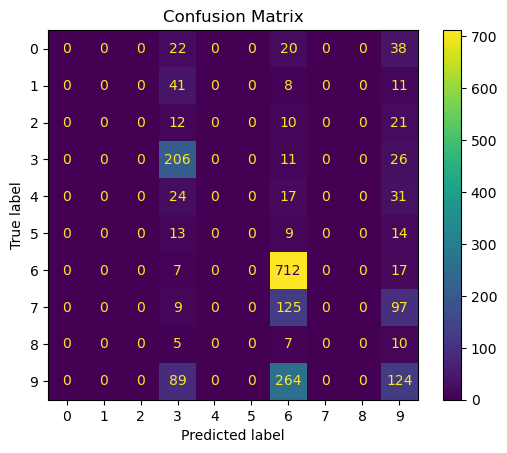

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [7]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

# Create model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Perform 5-fold cross validation
cv_scores = cross_val_score(rf_model, X, y, cv=5)

print("Cross Validation Scores:", cv_scores)
print("Average CV Score:", cv_scores.mean())

Cross Validation Scores: [0.8125 0.8145 0.808  0.8095 0.815 ]
Average CV Score: 0.8119


In [8]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define model
rf = RandomForestClassifier(random_state=42)

# Parameter grid
param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Grid Search
grid = GridSearchCV(rf, param_grid, cv=3, n_jobs=-1, verbose=2)
grid.fit(X_train, y_train)

# Best results
print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 150}
Best Score: 0.8102501347121557


In [9]:
import joblib
from sklearn.ensemble import RandomForestClassifier

# Final model with best params
final_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

# Train on full data
final_model.fit(X, y)

# Save model
joblib.dump(final_model, "crop_model.pkl")

print("Final model saved ✅")

Final model saved ✅


In [10]:
import joblib
import pandas as pd

model = joblib.load("crop_model.pkl")
encoders = joblib.load("encoders.pkl")
features = joblib.load("crop_features.pkl")

In [11]:
def predict_crop(user_input):
    df_input = pd.DataFrame([user_input])

    # Encode categorical columns
    for col in encoders:
        if col in df_input:
            df_input[col] = encoders[col].transform(df_input[col])

    # Ensure correct column order
    df_input = df_input.reindex(columns=features)

    # Predict
    prediction = model.predict(df_input)[0]

    # Decode output
    crop_name = encoders["Recommended_Crop"].inverse_transform([prediction])[0]

    return crop_name

In [12]:
sample = {
    'N': 90,
    'P': 40,
    'K': 40,
    'Soil_pH': 6.5,
    'Soil_Moisture': 50,
    'Soil_Type': 'Loamy',
    'Organic_Carbon': 0.8,
    'Electrical_Conductivity': 1.2,
    'Temperature': 25,
    'Humidity': 60,
    'Rainfall': 1000,
    'Sunlight_Hours': 8,
    'Wind_Speed': 5,
    'Region': 'South',
    'Altitude': 200,
    'Season': 'Kharif',
    'Irrigation_Type': 'Drip',
    'Fertilizer_Used': 100,
    'Previous_Crop': 'Wheat'
}

print("Recommended Crop:", predict_crop(sample))

Recommended Crop: Potato


                    Feature  Importance
10                 Rainfall    0.300040
8               Temperature    0.287509
3                   Soil_pH    0.088875
0                         N    0.049342
4             Soil_Moisture    0.023037
17          Fertilizer_Used    0.022946
11           Sunlight_Hours    0.022351
7   Electrical_Conductivity    0.022345
14                 Altitude    0.022259
9                  Humidity    0.021991
12               Wind_Speed    0.021959
6            Organic_Carbon    0.021858
2                         K    0.021021
1                         P    0.020757
15                   Season    0.011634
18            Previous_Crop    0.011618
5                 Soil_Type    0.011362
13                   Region    0.010147
16          Irrigation_Type    0.008948


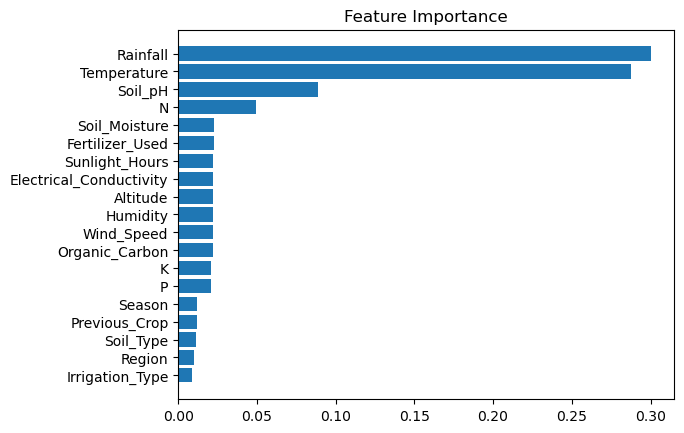

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

importances = final_model.feature_importances_
features_list = X.columns

feat_df = pd.DataFrame({
    'Feature': features_list,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feat_df)

# Plot
plt.figure()
plt.barh(feat_df['Feature'], feat_df['Importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np

# Train model ONLY on training data
rf_test_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

rf_test_model.fit(X_train, y_train)

# Full prediction
y_pred_full = rf_test_model.predict(X_test)

# Reduced version
X_test_reduced = X_test.copy()

low_importance_features = [
    'P','K','Soil_Moisture','Soil_Type','Organic_Carbon',
    'Electrical_Conductivity','Humidity','Sunlight_Hours',
    'Wind_Speed','Altitude','Season','Irrigation_Type',
    'Fertilizer_Used','Previous_Crop','Region'
]

for col in low_importance_features:
    if X[col].dtype in ['int64','float64']:
        X_test_reduced[col] = X[col].median()
    else:
        X_test_reduced[col] = X[col].mode()[0]

y_pred_reduced = rf_test_model.predict(X_test_reduced)

# Accuracy
acc_full = accuracy_score(y_test, y_pred_full)
acc_reduced = accuracy_score(y_test, y_pred_reduced)

print("Correct Full Accuracy   :", round(acc_full, 4))
print("Reduced Input Accuracy  :", round(acc_reduced, 4))
print("Actual Accuracy Drop    :", round(acc_full - acc_reduced, 4))

Correct Full Accuracy   : 0.807
Reduced Input Accuracy  : 0.8015
Actual Accuracy Drop    : 0.0055


In [32]:
import pandas as pd
import joblib

# Load everything once
model = joblib.load("crop_model.pkl")
encoders = joblib.load("encoders.pkl")
features = joblib.load("crop_features.pkl")

def predict_crop_final(N, Soil_pH, Temperature, Rainfall, Region="North"):
    
    # Step 1: User input (minimal)
    user_data = {
        'N': N,
        'Soil_pH': Soil_pH,
        'Temperature': Temperature,
        'Rainfall': Rainfall,
        'Region': Region
    }

    # Step 2: Smart defaults (based on your dataset)
    user_data.update({
        'P': 40,
        'K': 40,
        'Soil_Moisture': 40,
        'Soil_Type': 'Loamy',
        'Organic_Carbon': 0.8,
        'Electrical_Conductivity': 1.0,
        'Humidity': 60,
        'Sunlight_Hours': 8,
        'Wind_Speed': 5,
        'Altitude': 200,
        'Season': 'Kharif',
        'Irrigation_Type': 'Drip',
        'Fertilizer_Used': 100,
        'Previous_Crop': 'Wheat'
    })

    # Step 3: Convert to DataFrame
    df_input = pd.DataFrame([user_data])

    # Step 4: Encode categorical safely
    for col in encoders:
        if col in df_input:
            df_input[col] = encoders[col].transform(df_input[col])

    # Step 5: Ensure correct order
    df_input = df_input.reindex(columns=features)

    # Step 6: Predict
    prediction = model.predict(df_input)[0]

    # Step 7: Decode output
    crop_name = encoders["Recommended_Crop"].inverse_transform([prediction])[0]

    return crop_name

In [18]:
result = predict_crop_final(
    N=90,
    Soil_pH=6.5,
    Temperature=25,
    Rainfall=1000,
    Region="South"
)

print("Recommended Crop:", result)

Recommended Crop: Potato
